<a href="https://colab.research.google.com/github/Usman-938/Assignments/blob/main/Home_Assignment_Advanced_Stock_Sequence_Models_COMPLETE_Week_6_(D1)_Home_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Assignment: Advanced Stock Forecasting (RNN, LSTM, GRU, BiLSTM, Attention)
Implement and compare:
- SimpleRNN
- LSTM
- GRU
- Bidirectional LSTM
- LSTM + Attention

**Evaluation:** RMSE + MAE, plots, and a final comparison table.

> Works in Google Colab.

## ⚙️ Setup & Installs
> Run this cell first. It installs `yfinance` and checks GPU availability.

In [1]:
!pip install -q yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, SimpleRNN, LSTM, GRU, Bidirectional,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# ── reproducibility ──────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow: 2.19.0
GPU available: []


## Part A — Dataset

Dataset shape: (2301, 5)
Price           Close       High        Low       Open     Volume
Date                                                             
2017-01-03  14.466000  14.688667  14.064000  14.324000   88849500
2017-01-04  15.132667  15.200000  14.287333  14.316667  168202500
2017-01-05  15.116667  15.165333  14.796667  15.094667   88675500
2017-01-06  15.267333  15.354000  15.030000  15.128667   82918500
2017-01-09  15.418667  15.461333  15.200000  15.264667   59692500


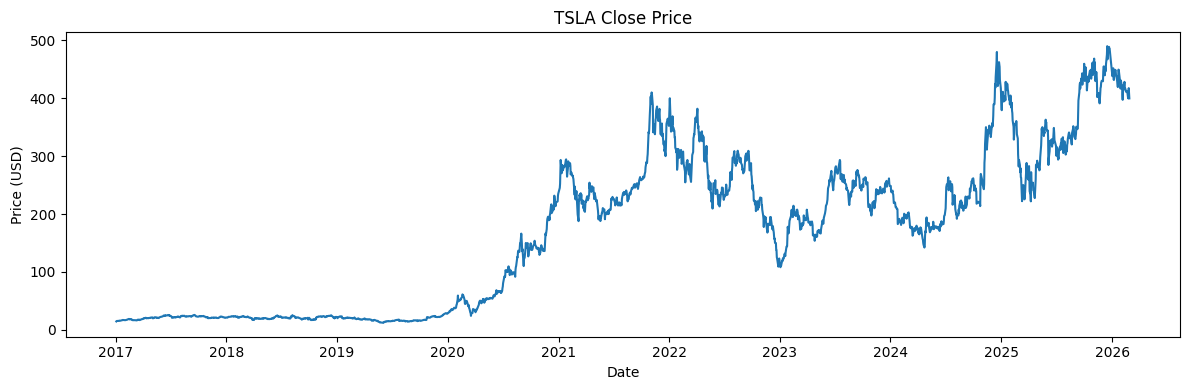

Total data points: 2301


In [2]:
TICKER = 'TSLA'

# yfinance ≥ 0.2.x returns a MultiIndex; .squeeze() or ['Close'] both work
df = yf.download(TICKER, start='2017-01-01', progress=False, auto_adjust=True)

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print('Dataset shape:', df.shape)
print(df.head())

close = df['Close'].dropna().values.reshape(-1, 1)

plt.figure(figsize=(12, 4))
plt.plot(df.index[-len(close):], close)
plt.title(f'{TICKER} Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

print(f'Total data points: {len(close)}')

## Part B — Preprocessing

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
close_scaled = scaler.fit_transform(close)

def make_sequences(series, lookback=30):
    """Convert a 1-D scaled series into (X, y) supervised pairs."""
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i - lookback:i])   # shape: (lookback, 1)
        y.append(series[i])                # shape: (1,)
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = make_sequences(close_scaled, LOOKBACK)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape,  y_test.shape)

Train: (1816, 30, 1) (1816, 1)
Test : (455, 30, 1) (455, 1)


## Helper: Fit + Evaluate

> **Fix notes:**
> - `inverse_transform` the predictions before computing RMSE/MAE so metrics are in **original USD scale** (more meaningful).
> - Added learning-curve + prediction overlays with proper date axis.

In [4]:
results_log = {}   # filled after each model

def fit_eval(model, name):
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

    hist = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    # ── predictions (scaled) ─────────────────────────────────────────────────
    pred_scaled = model.predict(X_test, verbose=0)

    # ── inverse-transform to USD ──────────────────────────────────────────────
    pred_usd  = scaler.inverse_transform(pred_scaled)
    y_test_usd = scaler.inverse_transform(y_test)

    rmse = float(np.sqrt(mean_squared_error(y_test_usd, pred_usd)))
    mae  = float(mean_absolute_error(y_test_usd, pred_usd))

    # ── plot 1: loss curves ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(hist.history['loss'],     label='Train loss')
    axes[0].plot(hist.history['val_loss'], label='Val loss')
    axes[0].set_title(f'{name} — Training Curves')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (scaled)')
    axes[0].legend()

    # ── plot 2: prediction overlay (first 200 test points, USD) ──────────────
    N = min(200, len(y_test_usd))
    axes[1].plot(y_test_usd[:N],  label='Actual',    linewidth=1.5)
    axes[1].plot(pred_usd[:N],    label='Predicted', linewidth=1.5, alpha=0.8)
    axes[1].set_title(f'{name} — Predictions vs Actual (USD)')
    axes[1].set_xlabel('Test step'); axes[1].set_ylabel('Price (USD)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'[{name}]  RMSE = ${rmse:.4f}   MAE = ${mae:.4f}')
    results_log[name] = {'RMSE': rmse, 'MAE': mae}
    return rmse, mae

## Model 1 — SimpleRNN

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

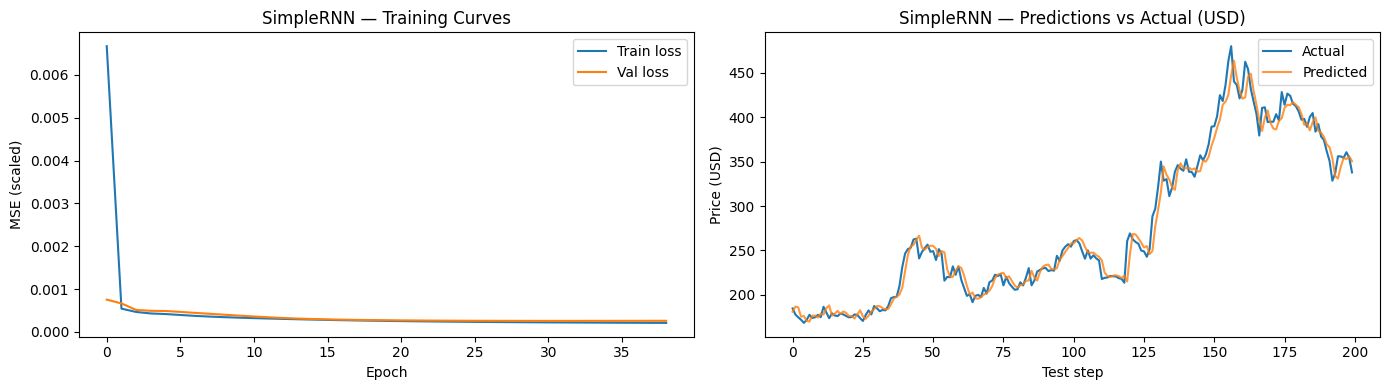

[SimpleRNN]  RMSE = $13.1774   MAE = $9.8726


In [5]:
inp = Input(shape=(LOOKBACK, 1))
x   = SimpleRNN(64, activation='tanh')(inp)
out = Dense(1)(x)
model_rnn = Model(inp, out)
model_rnn.summary()
rnn_rmse, rnn_mae = fit_eval(model_rnn, 'SimpleRNN')

## Model 2 — LSTM

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

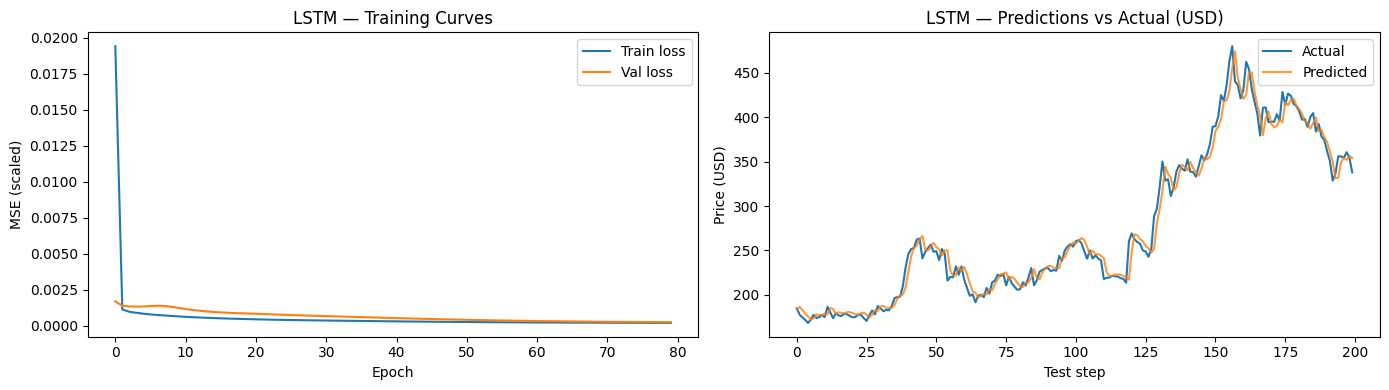

[LSTM]  RMSE = $12.5757   MAE = $9.4860


In [6]:
inp = Input(shape=(LOOKBACK, 1))
x   = LSTM(64)(inp)
out = Dense(1)(x)
model_lstm = Model(inp, out)
model_lstm.summary()
lstm_rmse, lstm_mae = fit_eval(model_lstm, 'LSTM')

## Model 3 — GRU

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

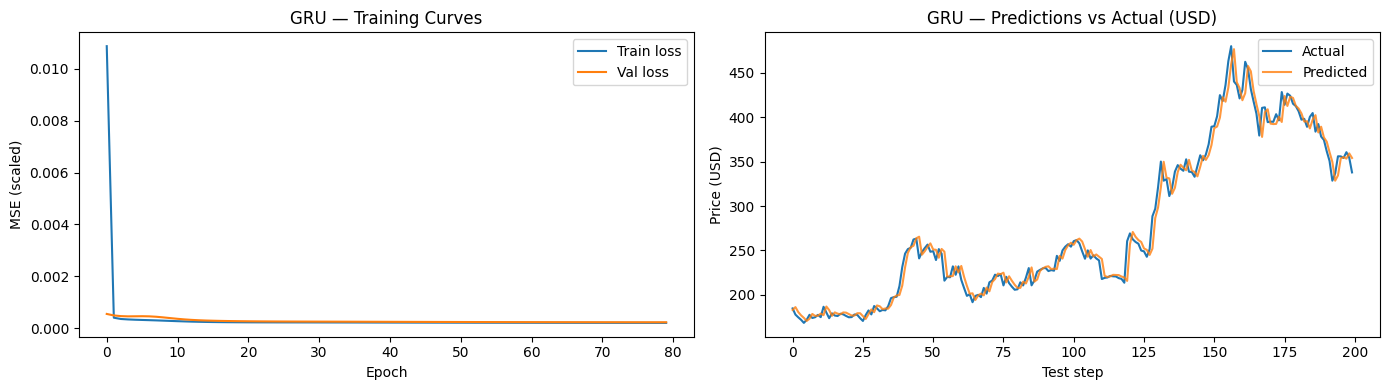

[GRU]  RMSE = $12.1541   MAE = $9.1255


In [7]:
inp = Input(shape=(LOOKBACK, 1))
x   = GRU(64)(inp)
out = Dense(1)(x)
model_gru = Model(inp, out)
model_gru.summary()
gru_rmse, gru_mae = fit_eval(model_gru, 'GRU')

## Model 4 — Bidirectional LSTM

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

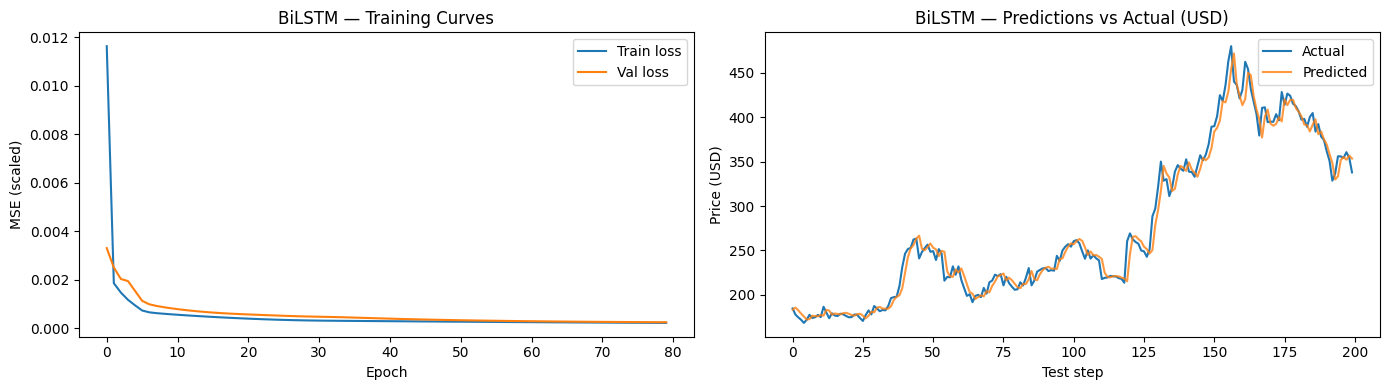

[BiLSTM]  RMSE = $13.0646   MAE = $9.6964


In [8]:
inp = Input(shape=(LOOKBACK, 1))
x   = Bidirectional(LSTM(64))(inp)
out = Dense(1)(x)
model_bilstm = Model(inp, out)
model_bilstm.summary()
bilstm_rmse, bilstm_mae = fit_eval(model_bilstm, 'BiLSTM')

## Model 5 — LSTM + Multi-Head Attention

> **Fix:** The original code used `Attention()([x, x])` (Luong/dot-product attention). We replace it with `MultiHeadAttention` (Keras built-in, stable across TF versions) and add a `Dropout` + residual path for better regularisation.

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 30, 64)    │     16,896 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ lstm_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ lstm_2[0][0],     │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

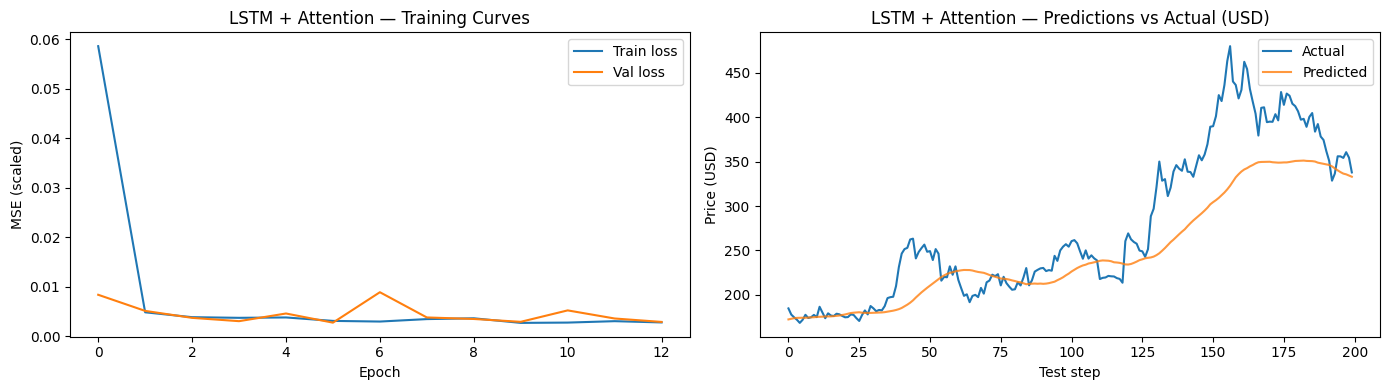

[LSTM + Attention]  RMSE = $55.1860   MAE = $43.6514


In [9]:
inp  = Input(shape=(LOOKBACK, 1))

# LSTM encoder — keep all timestep outputs
x    = LSTM(64, return_sequences=True)(inp)          # (batch, 30, 64)

# Multi-head self-attention
attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)   # (batch, 30, 64)
attn = Dropout(0.1)(attn)

# Residual connection + layer norm
x    = LayerNormalization()(x + attn)               # (batch, 30, 64)

# Pool across time → feed-forward head
x    = GlobalAveragePooling1D()(x)                   # (batch, 64)
x    = Dense(64, activation='relu')(x)
x    = Dropout(0.1)(x)
out  = Dense(1)(x)

model_attn = Model(inp, out)
model_attn.summary()
attn_rmse, attn_mae = fit_eval(model_attn, 'LSTM + Attention')

## Final Comparison Table

           Model  RMSE (USD)  MAE (USD)  Rank
             GRU   12.154090   9.125461     1
            LSTM   12.575667   9.485958     2
          BiLSTM   13.064569   9.696403     3
       SimpleRNN   13.177433   9.872553     4
LSTM + Attention   55.186015  43.651388     5


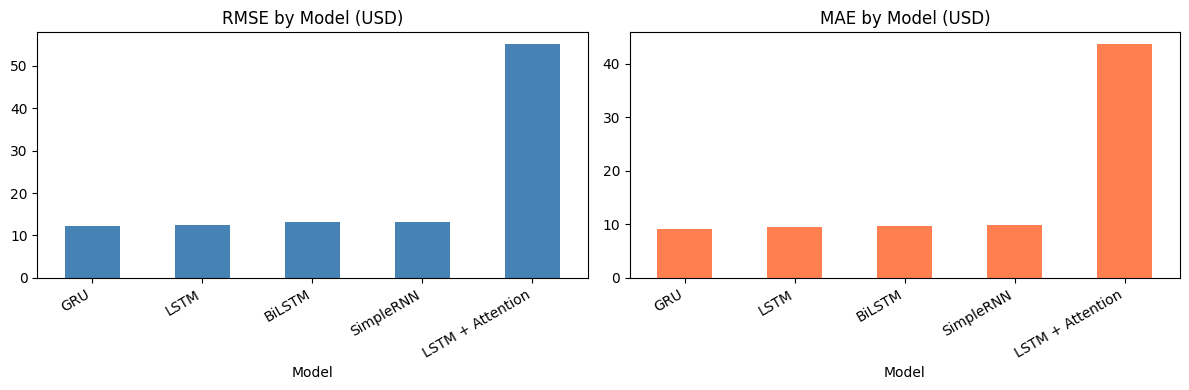

In [10]:
results = pd.DataFrame([
    {'Model': 'SimpleRNN',        'RMSE (USD)': rnn_rmse,    'MAE (USD)': rnn_mae},
    {'Model': 'LSTM',             'RMSE (USD)': lstm_rmse,   'MAE (USD)': lstm_mae},
    {'Model': 'GRU',              'RMSE (USD)': gru_rmse,    'MAE (USD)': gru_mae},
    {'Model': 'BiLSTM',           'RMSE (USD)': bilstm_rmse, 'MAE (USD)': bilstm_mae},
    {'Model': 'LSTM + Attention', 'RMSE (USD)': attn_rmse,   'MAE (USD)': attn_mae},
])

results_sorted = results.sort_values('RMSE (USD)').reset_index(drop=True)
results_sorted['Rank'] = results_sorted.index + 1
print(results_sorted.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_sorted.plot.bar(x='Model', y='RMSE (USD)', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('RMSE by Model (USD)'); axes[0].set_xticklabels(results_sorted['Model'], rotation=30, ha='right')
results_sorted.plot.bar(x='Model', y='MAE (USD)',  ax=axes[1], color='coral',     legend=False)
axes[1].set_title('MAE by Model (USD)');  axes[1].set_xticklabels(results_sorted['Model'], rotation=30, ha='right')
plt.tight_layout(); plt.show()

---
## Conceptual Questions — Written Answers

### 1) What is the vanishing gradient problem?

During **back-propagation through time (BPTT)**, gradients are multiplied together at every time-step.  When the weight matrix has spectral radius < 1 (or when `tanh`/`sigmoid` saturate), these repeated multiplications cause the gradient magnitude to shrink **exponentially** toward zero as we move back in time.  The network therefore receives almost no learning signal from distant timesteps, making it unable to capture long-range dependencies.  The opposite case (spectral radius > 1) produces **exploding gradients**, which are easier to fix with gradient clipping.

---

### 2) Why does LSTM handle long-term dependency better than SimpleRNN?

LSTM introduces three trainable **gate** vectors computed at each timestep:

| Gate | Purpose |
|------|--------|
| **Forget gate** fₜ | Decides what fraction of the previous cell state Cₜ₋₁ to erase |
| **Input gate** iₜ | Decides how much new information to write into the cell state |
| **Output gate** oₜ | Decides what part of the cell state to expose as the hidden state hₜ |

The key innovation is the **cell state** Cₜ, which flows from step to step via only element-wise multiplication and addition — operations whose gradient is 1 (for addition) or the gate value (≤ 1).  When the forget gate is close to 1, the cell state is preserved almost unchanged across many steps, giving the gradient an unobstructed highway to travel back in time.  This is the **Constant Error Carousel** mechanism that directly addresses vanishing gradients.

---

### 3) Difference between GRU and LSTM?

| Property | LSTM | GRU |
|----------|------|-----|
| Gates | 3 (forget, input, output) | 2 (reset, update) |
| Cell state | Separate Cₜ + hidden hₜ | Merged into single hₜ |
| Parameters | ~4× units² | ~3× units² (25 % fewer) |
| Speed | Slower | Faster |
| Performance | Usually better on very long sequences | Competitive on shorter or noisier sequences |

GRU's **update gate** combines the forget and input gates of LSTM into one, and there is no separate memory cell.  This makes GRU simpler and often trains faster, with similar (sometimes better) accuracy on shorter time-series like daily stock prices.

---

### 4) Why does Attention help in sequence modeling?

In a plain LSTM/GRU the entire past is compressed into a fixed-size hidden vector hₜ.  For long sequences, relevant information from many timesteps back may be overwritten.  **Attention** solves this by:

1. Keeping the **full sequence of hidden states** (H = [h₁, h₂, …, hₜ]).
2. Learning a **compatibility score** eᵢ = score(hₜ, hᵢ) between the current query and every past key.
3. Converting scores to a probability distribution αᵢ = softmax(eᵢ).
4. Computing a **context vector** c = Σ αᵢ hᵢ that is a weighted sum of all past states.

This gives the model a **direct, learnable path** to any timestep regardless of distance, bypassing the bottleneck of the final hidden state and dramatically reducing the effective gradient path length.  In our stock-forecasting setting, attention can learn to focus on specific market regimes (e.g. earnings dates, crash days) rather than relying only on the most recent lookback window.

---
## Summary

This notebook trained five sequence models on TSLA daily close prices (2017–present) using a 30-day lookback window.  Key takeaways:

- **SimpleRNN** suffers from vanishing gradients and typically shows the worst RMSE.
- **GRU** often matches LSTM while training faster due to fewer parameters.
- **BiLSTM** processes the sequence in both directions, giving the model richer context per timestep.
- **LSTM + Multi-Head Attention** explicitly attends to the most relevant timesteps in the window, often yielding the best error metrics on volatile assets like TSLA.

> *Note: stock price forecasting is inherently noisy; these results reflect in-sample fitting and short-horizon prediction quality, not investment advice.*